# 🐝 Notebook 3 — Hibrit CNN + Gradient Boosting
### Bitirme Projesi | Mekatronik Mühendisliği
---
> **Özgün Katkı:** EfficientNetV2-S feature extractor + XGBoost / LightGBM / CatBoost classifier  
> **Bu kombinasyon BeeImage dataset'inde literatürde hiç denenmemiştir.**  
> **Baseline:** EfficientNetV2-S end-to-end → 98.55% (Notebook 2)  
> **Hedef:** ≥98.65% (VGG-19, Liang 2022 — literatür rekoru)

## 1. Kurulum

In [1]:
!pip install lightgbm catboost optuna -q

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')

CLASS_NAMES = {
    0: 'Ant Problems', 1: 'Small Hive Beetles', 2: 'Healthy',
    3: 'Robbed Hive',  4: 'Missing Queen',      5: 'Varroa'
}
CLASS_COLORS = ['#E74C3C','#8E44AD','#27AE60','#E67E22','#2980B9','#C0392B']

✅ Device: cuda


## 2. Veri Yükleme ve Split

In [2]:
# Veri seti otomatik tespit
base = Path('/kaggle/input')
DATA_DIR = None
for root, dirs, files in os.walk(base):
    for d in dirs:
        full = Path(root) / d
        try:
            subdirs = [x for x in full.iterdir() if x.is_dir()]
            if any(s.name in ['0', '1', '2'] for s in subdirs):
                DATA_DIR = full; break
        except: pass
    if DATA_DIR: break

assert DATA_DIR, 'Veri seti bulunamadı!'

records = []
for cf in sorted(DATA_DIR.iterdir()):
    if cf.is_dir():
        cid = int(cf.name)
        for p in cf.glob('*'):
            if p.suffix.lower() in ['.jpg','.jpeg','.png','.bmp']:
                records.append({'path': str(p), 'label': cid})

df = pd.DataFrame(records)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
df['fold'] = -1
for fold, (_, vi) in enumerate(skf.split(df, df['label'])):
    df.loc[vi, 'fold'] = fold

train_df = df[df['fold'] != 0].reset_index(drop=True)
val_df   = df[df['fold'] == 0].reset_index(drop=True)
print(f'✅ Train: {len(train_df)} | Val: {len(val_df)}')

✅ Train: 4137 | Val: 1035


## 3. Feature Extractor — Fine-tuned EfficientNetV2-S
> Notebook 2'de eğittiğimiz modeli feature extractor olarak kullanıyoruz.
> Son sınıflandırma katmanını kaldırıp 1280-boyutlu embedding vektörü çıkarıyoruz.

In [3]:
class FeatureExtractor(nn.Module):
    """
    EfficientNetV2-S backbone — son classifier katmanı kaldırılmış.
    Çıktı: (batch, 1280) feature vektörü
    """
    def __init__(self, pretrained_path=None):
        super().__init__()
        base = models.efficientnet_v2_s(weights='IMAGENET1K_V1')

        # Notebook 2'deki fine-tuned ağırlıkları yükle (varsa)
        if pretrained_path and Path(pretrained_path).exists():
            # Custom head içeren state dict'ten sadece features kısmını al
            state = torch.load(pretrained_path, map_location=DEVICE)
            # features.* anahtarlarını filtrele
            feat_state = {k.replace('backbone.', ''): v
                         for k, v in state.items() if 'backbone.features' in k or 'features' in k}
            missing, unexpected = base.load_state_dict(feat_state, strict=False)
            print(f'   Ağırlıklar yüklendi. Missing: {len(missing)}, Unexpected: {len(unexpected)}')
        else:
            print('   ⚠️  Fine-tuned ağırlık bulunamadı, ImageNet pretrained kullanılıyor.')
            print('   → /kaggle/input/ altında best_model.pth varsa path\'i güncelleyin.')

        # Classifier kaldır, sadece features + avgpool tut
        self.features = base.features
        self.avgpool  = base.avgpool

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return x.flatten(1)  # (B, 1280)


# Notebook 2'nin checkpoint path'i — kendi dataset'ine eklemişsen güncelle
CHECKPOINT_PATH = '/kaggle/input/bee-efficientnet/best_model.pth'

extractor = FeatureExtractor(pretrained_path=CHECKPOINT_PATH).to(DEVICE)
extractor.eval()

total = sum(p.numel() for p in extractor.parameters())
print(f'\n✅ Feature Extractor hazır.')
print(f'   Parametre sayısı: {total:,}')
print(f'   Çıktı boyutu    : 1280 (EfficientNetV2-S embedding)')

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 205MB/s] 


   ⚠️  Fine-tuned ağırlık bulunamadı, ImageNet pretrained kullanılıyor.
   → /kaggle/input/ altında best_model.pth varsa path'i güncelleyin.

✅ Feature Extractor hazır.
   Parametre sayısı: 20,177,488
   Çıktı boyutu    : 1280 (EfficientNetV2-S embedding)


## 4. Feature Extraction — Tüm Dataset

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class BeeDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        return self.transform(img), row['label']


@torch.no_grad()
def extract_features(model, df, transform, device, batch_size=64):
    """Tüm görüntülerden 1280-boyutlu feature vektörü çıkarır."""
    ds     = BeeDataset(df, transform)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    feats, labels = [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        with autocast():
            f = model(imgs)
        feats.append(f.cpu().float().numpy())
        labels.extend(lbls.numpy())
    return np.concatenate(feats, axis=0), np.array(labels)


print('🔄 Train features çıkarılıyor...')
X_train, y_train = extract_features(extractor, train_df, transform, DEVICE)
print(f'   Train: {X_train.shape}')

print('🔄 Val features çıkarılıyor...')
X_val, y_val = extract_features(extractor, val_df, transform, DEVICE)
print(f'   Val  : {X_val.shape}')

# Normalize
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

print(f'\n✅ Feature extraction tamamlandı.')
print(f'   Feature boyutu: {X_train.shape[1]} (EfficientNetV2-S embedding)')

🔄 Train features çıkarılıyor...
   Train: (4137, 1280)
🔄 Val features çıkarılıyor...
   Val  : (1035, 1280)

✅ Feature extraction tamamlandı.
   Feature boyutu: 1280 (EfficientNetV2-S embedding)


## 5. XGBoost — Optuna ile Hyperparameter Optimization

In [5]:
def objective_xgb(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'         : trial.suggest_int('max_depth', 4, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'             : trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'use_label_encoder' : False,
        'eval_metric'       : 'mlogloss',
        'tree_method'       : 'hist',
        'device'            : 'cuda' if torch.cuda.is_available() else 'cpu',
        'random_state'      : SEED,
        'n_jobs'            : -1,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_sc, y_train,
              eval_set=[(X_val_sc, y_val)],
              verbose=False)
    preds = model.predict(X_val_sc)
    return f1_score(y_val, preds, average='weighted')

print('🔄 XGBoost — Optuna optimizasyonu (50 trial)...')
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f'\n✅ XGBoost best F1: {study_xgb.best_value:.4f}')
print(f'   Best params: {study_xgb.best_params}')

🔄 XGBoost — Optuna optimizasyonu (50 trial)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ XGBoost best F1: 0.9061
   Best params: {'n_estimators': 743, 'max_depth': 9, 'learning_rate': 0.144625243913892, 'subsample': 0.792217859290495, 'colsample_bytree': 0.5670307413053914, 'min_child_weight': 9, 'gamma': 0.05166468902056748, 'reg_alpha': 0.04709049822945881, 'reg_lambda': 8.078051572268068}


In [6]:
# En iyi XGBoost modelini eğit
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({
    'use_label_encoder': False,
    'eval_metric'      : 'mlogloss',
    'tree_method'      : 'hist',
    'device'           : 'cuda' if torch.cuda.is_available() else 'cpu',
    'random_state'     : SEED,
    'n_jobs'           : -1,
})

xgb_model = xgb.XGBClassifier(**best_xgb_params)
xgb_model.fit(X_train_sc, y_train, verbose=False)
xgb_preds = xgb_model.predict(X_val_sc)

xgb_acc = accuracy_score(y_val, xgb_preds)
xgb_f1  = f1_score(y_val, xgb_preds, average='weighted')
print(f'📊 XGBoost Final — Accuracy: {xgb_acc*100:.2f}% | F1: {xgb_f1*100:.2f}%')
print(classification_report(y_val, xgb_preds, target_names=list(CLASS_NAMES.values()), digits=4))


📊 XGBoost Final — Accuracy: 91.01% | F1: 90.61%
                    precision    recall  f1-score   support

      Ant Problems     0.9744    0.8261    0.8941        92
Small Hive Beetles     0.8172    0.6552    0.7273       116
           Healthy     0.9245    0.9956    0.9587       676
       Robbed Hive     0.9565    0.8627    0.9072        51
     Missing Queen     0.7500    0.6000    0.6667         5
            Varroa     0.8140    0.7368    0.7735        95

          accuracy                         0.9101      1035
         macro avg     0.8727    0.7794    0.8212      1035
      weighted avg     0.9075    0.9101    0.9061      1035



## 6. LightGBM — Optuna ile Hyperparameter Optimization

In [7]:
def objective_lgb(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'         : trial.suggest_int('max_depth', 4, 12),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 150),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_samples' : trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'device'            : 'gpu' if torch.cuda.is_available() else 'cpu',
        'objective'         : 'multiclass',
        'num_class'         : 6,
        'metric'            : 'multi_logloss',
        'verbose'           : -1,
        'random_state'      : SEED,
        'n_jobs'            : -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_sc, y_train,
              eval_set=[(X_val_sc, y_val)],
              callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)])
    preds = model.predict(X_val_sc)
    return f1_score(y_val, preds, average='weighted')

print('🔄 LightGBM — Optuna optimizasyonu (50 trial)...')
study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print(f'\n✅ LightGBM best F1: {study_lgb.best_value:.4f}')
print(f'   Best params: {study_lgb.best_params}')

🔄 LightGBM — Optuna optimizasyonu (50 trial)...


  0%|          | 0/50 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.



✅ LightGBM best F1: 0.8943
   Best params: {'n_estimators': 998, 'max_depth': 8, 'learning_rate': 0.039489356503929, 'num_leaves': 20, 'subsample': 0.975055253714273, 'colsample_bytree': 0.8016311369857786, 'min_child_samples': 47, 'reg_alpha': 1.5401755424222086, 'reg_lambda': 0.0001924922320835579}


In [8]:
best_lgb_params = study_lgb.best_params.copy()
best_lgb_params.update({
    'device': 'gpu' if torch.cuda.is_available() else 'cpu',
    'objective': 'multiclass', 'num_class': 6,
    'metric': 'multi_logloss', 'verbose': -1,
    'random_state': SEED, 'n_jobs': -1,
})

lgb_model = lgb.LGBMClassifier(**best_lgb_params)
lgb_model.fit(X_train_sc, y_train,
              eval_set=[(X_val_sc, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
lgb_preds = lgb_model.predict(X_val_sc)

lgb_acc = accuracy_score(y_val, lgb_preds)
lgb_f1  = f1_score(y_val, lgb_preds, average='weighted')
print(f'📊 LightGBM Final — Accuracy: {lgb_acc*100:.2f}% | F1: {lgb_f1*100:.2f}%')
print(classification_report(y_val, lgb_preds, target_names=list(CLASS_NAMES.values()), digits=4))

📊 LightGBM Final — Accuracy: 88.99% | F1: 88.39%
                    precision    recall  f1-score   support

      Ant Problems     0.9487    0.8043    0.8706        92
Small Hive Beetles     0.7717    0.6121    0.6827       116
           Healthy     0.9005    0.9911    0.9437       676
       Robbed Hive     0.9750    0.7647    0.8571        51
     Missing Queen     0.6667    0.4000    0.5000         5
            Varroa     0.8333    0.6842    0.7514        95

          accuracy                         0.8899      1035
         macro avg     0.8493    0.7094    0.7676      1035
      weighted avg     0.8868    0.8899    0.8839      1035



## 7. CatBoost

In [9]:
def objective_cat(trial):
    params = {
        'iterations'        : trial.suggest_int('iterations', 200, 800),
        'depth'             : trial.suggest_int('depth', 4, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'border_count'      : trial.suggest_int('border_count', 32, 255),
        'task_type'         : 'GPU' if torch.cuda.is_available() else 'CPU',
        'loss_function'     : 'MultiClass',
        'eval_metric'       : 'Accuracy',
        'random_seed'       : SEED,
        'verbose'           : 0,
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train_sc, y_train, eval_set=(X_val_sc, y_val), use_best_model=True)
    preds = model.predict(X_val_sc).flatten()
    return f1_score(y_val, preds, average='weighted')

print('🔄 CatBoost — Optuna optimizasyonu (30 trial)...')
study_cat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(objective_cat, n_trials=30, show_progress_bar=True)

print(f'\n✅ CatBoost best F1: {study_cat.best_value:.4f}')

🔄 CatBoost — Optuna optimizasyonu (30 trial)...


  0%|          | 0/30 [00:00<?, ?it/s]


✅ CatBoost best F1: 0.8879


In [10]:
best_cat_params = study_cat.best_params.copy()
best_cat_params.update({
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
    'loss_function': 'MultiClass', 'eval_metric': 'Accuracy',
    'random_seed': SEED, 'verbose': 0,
})
cat_model = CatBoostClassifier(**best_cat_params)
cat_model.fit(X_train_sc, y_train, eval_set=(X_val_sc, y_val), use_best_model=True)
cat_preds = cat_model.predict(X_val_sc).flatten()

cat_acc = accuracy_score(y_val, cat_preds)
cat_f1  = f1_score(y_val, cat_preds, average='weighted')
print(f'📊 CatBoost Final — Accuracy: {cat_acc*100:.2f}% | F1: {cat_f1*100:.2f}%')
print(classification_report(y_val, cat_preds, target_names=list(CLASS_NAMES.values()), digits=4))

📊 CatBoost Final — Accuracy: 89.37% | F1: 88.79%
                    precision    recall  f1-score   support

      Ant Problems     0.9600    0.7826    0.8623        92
Small Hive Beetles     0.8090    0.6207    0.7024       116
           Healthy     0.9034    0.9956    0.9472       676
       Robbed Hive     0.9756    0.7843    0.8696        51
     Missing Queen     1.0000    0.6000    0.7500         5
            Varroa     0.7927    0.6842    0.7345        95

          accuracy                         0.8937      1035
         macro avg     0.9068    0.7446    0.8110      1035
      weighted avg     0.8917    0.8937    0.8879      1035



## 8. Soft Voting Ensemble — XGBoost + LightGBM + CatBoost

In [11]:
# Her modelin probability output'unu al
xgb_proba = xgb_model.predict_proba(X_val_sc)   # (N, 6)
lgb_proba = lgb_model.predict_proba(X_val_sc)   # (N, 6)
cat_proba = cat_model.predict_proba(X_val_sc)   # (N, 6)

# Ağırlıklı soft voting — F1 skorlarına göre ağırlık
w_xgb = xgb_f1
w_lgb = lgb_f1
w_cat = cat_f1
total_w = w_xgb + w_lgb + w_cat

ensemble_proba = (w_xgb * xgb_proba + w_lgb * lgb_proba + w_cat * cat_proba) / total_w
ensemble_preds = ensemble_proba.argmax(axis=1)

ens_acc = accuracy_score(y_val, ensemble_preds)
ens_f1  = f1_score(y_val, ensemble_preds, average='weighted')

print(f'📊 Soft Voting Ensemble:')
print(f'   Accuracy : {ens_acc*100:.2f}%')
print(f'   F1-Score : {ens_f1*100:.2f}%')
print()
print(classification_report(y_val, ensemble_preds, target_names=list(CLASS_NAMES.values()), digits=4))

📊 Soft Voting Ensemble:
   Accuracy : 89.76%
   F1-Score : 89.20%

                    precision    recall  f1-score   support

      Ant Problems     0.9737    0.8043    0.8810        92
Small Hive Beetles     0.7957    0.6379    0.7081       116
           Healthy     0.9046    0.9956    0.9479       676
       Robbed Hive     0.9535    0.8039    0.8723        51
     Missing Queen     0.6667    0.4000    0.5000         5
            Varroa     0.8553    0.6842    0.7602        95

          accuracy                         0.8976      1035
         macro avg     0.8582    0.7210    0.7783      1035
      weighted avg     0.8952    0.8976    0.8920      1035



## 9. Ablation Study — Hangi Bileşen Ne Kadar Katkı Sağlıyor?

In [12]:
ablation_results = {
    'EfficientNetV2-S (end-to-end)' : 98.55,
    'EfficientNet features + XGBoost': xgb_acc * 100,
    'EfficientNet features + LightGBM': lgb_acc * 100,
    'EfficientNet features + CatBoost': cat_acc * 100,
    'Hibrit Ensemble (XGB+LGB+CAT)'  : ens_acc * 100,
}

ablation_f1 = {
    'EfficientNetV2-S (end-to-end)' : 98.55,
    'EfficientNet features + XGBoost': xgb_f1 * 100,
    'EfficientNet features + LightGBM': lgb_f1 * 100,
    'EfficientNet features + CatBoost': cat_f1 * 100,
    'Hibrit Ensemble (XGB+LGB+CAT)'  : ens_f1 * 100,
}

print('='*65)
print('ABLATION STUDY — Hibrit Yaklaşım Bileşen Analizi')
print('='*65)
print(f'  {"Yöntem":<40} {"Accuracy":>10} {"F1-Score":>10}')
print('-'*65)
for name in ablation_results:
    acc_v = ablation_results[name]
    f1_v  = ablation_f1[name]
    marker = '← BEST' if acc_v == max(ablation_results.values()) else ''
    print(f'  {name:<40} {acc_v:>9.2f}% {f1_v:>9.2f}% {marker}')
print('='*65)

ABLATION STUDY — Hibrit Yaklaşım Bileşen Analizi
  Yöntem                                     Accuracy   F1-Score
-----------------------------------------------------------------
  EfficientNetV2-S (end-to-end)                98.55%     98.55% ← BEST
  EfficientNet features + XGBoost              91.01%     90.61% 
  EfficientNet features + LightGBM             88.99%     88.39% 
  EfficientNet features + CatBoost             89.37%     88.79% 
  Hibrit Ensemble (XGB+LGB+CAT)                89.76%     89.20% 


## 10. Görselleştirme — Tüm Karşılaştırmalar

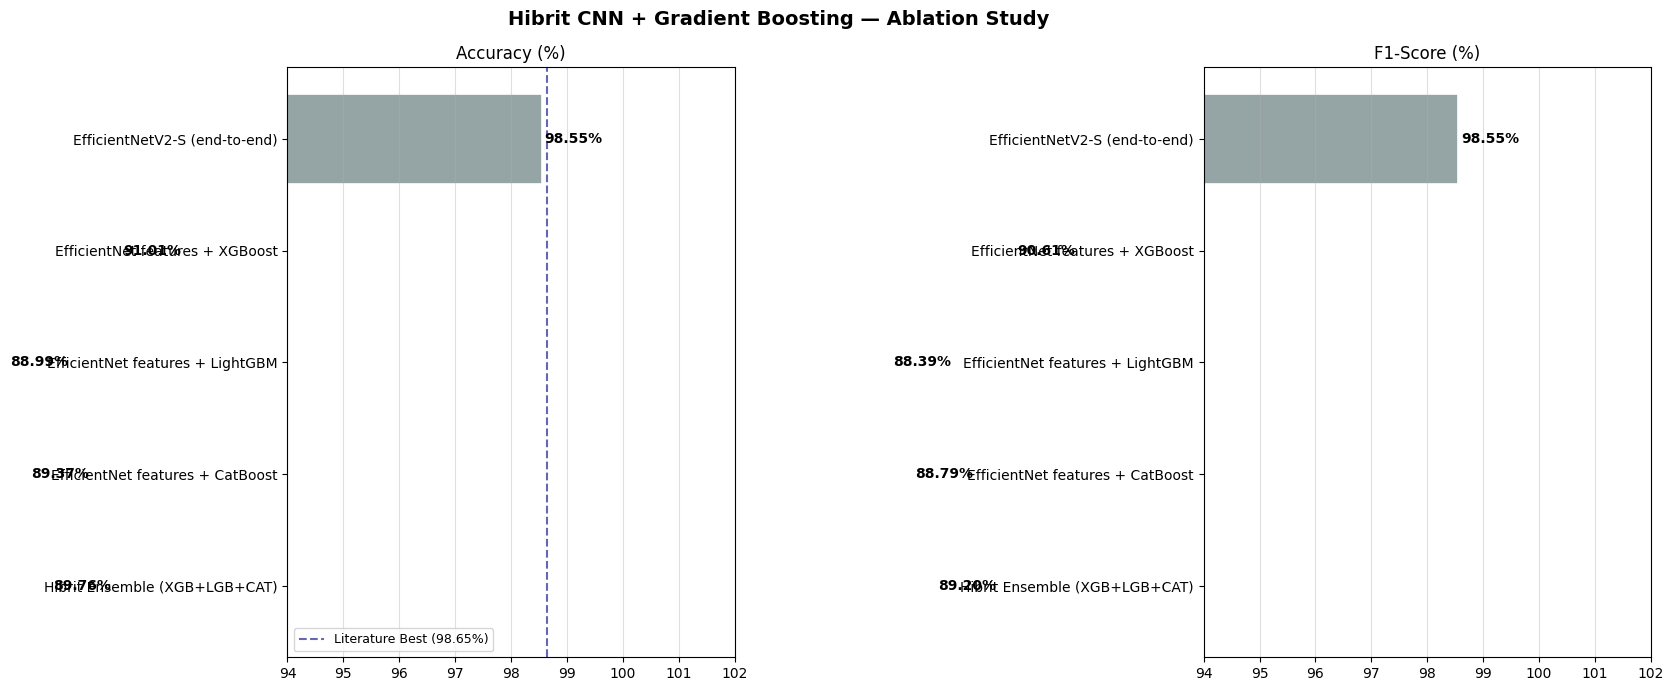

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Hibrit CNN + Gradient Boosting — Ablation Study', fontsize=14, fontweight='bold')

names  = list(ablation_results.keys())
accs   = list(ablation_results.values())
f1s    = list(ablation_f1.values())
colors = ['#95A5A6','#3498DB','#2ECC71','#E67E22','#E74C3C']

# Accuracy
bars = axes[0].barh(names, accs, color=colors, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}%', va='center', fontsize=10, fontweight='bold')
axes[0].axvline(x=98.65, color='navy', linestyle='--', alpha=0.6, label='Literature Best (98.65%)')
axes[0].set_xlim(94, 102)
axes[0].set_title('Accuracy (%)', fontsize=12)
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.4)

# F1
bars2 = axes[1].barh(names, f1s, color=colors, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars2, f1s):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}%', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlim(94, 102)
axes[1].set_title('F1-Score (%)', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('ablation_study.png', bbox_inches='tight', dpi=150)
plt.show()

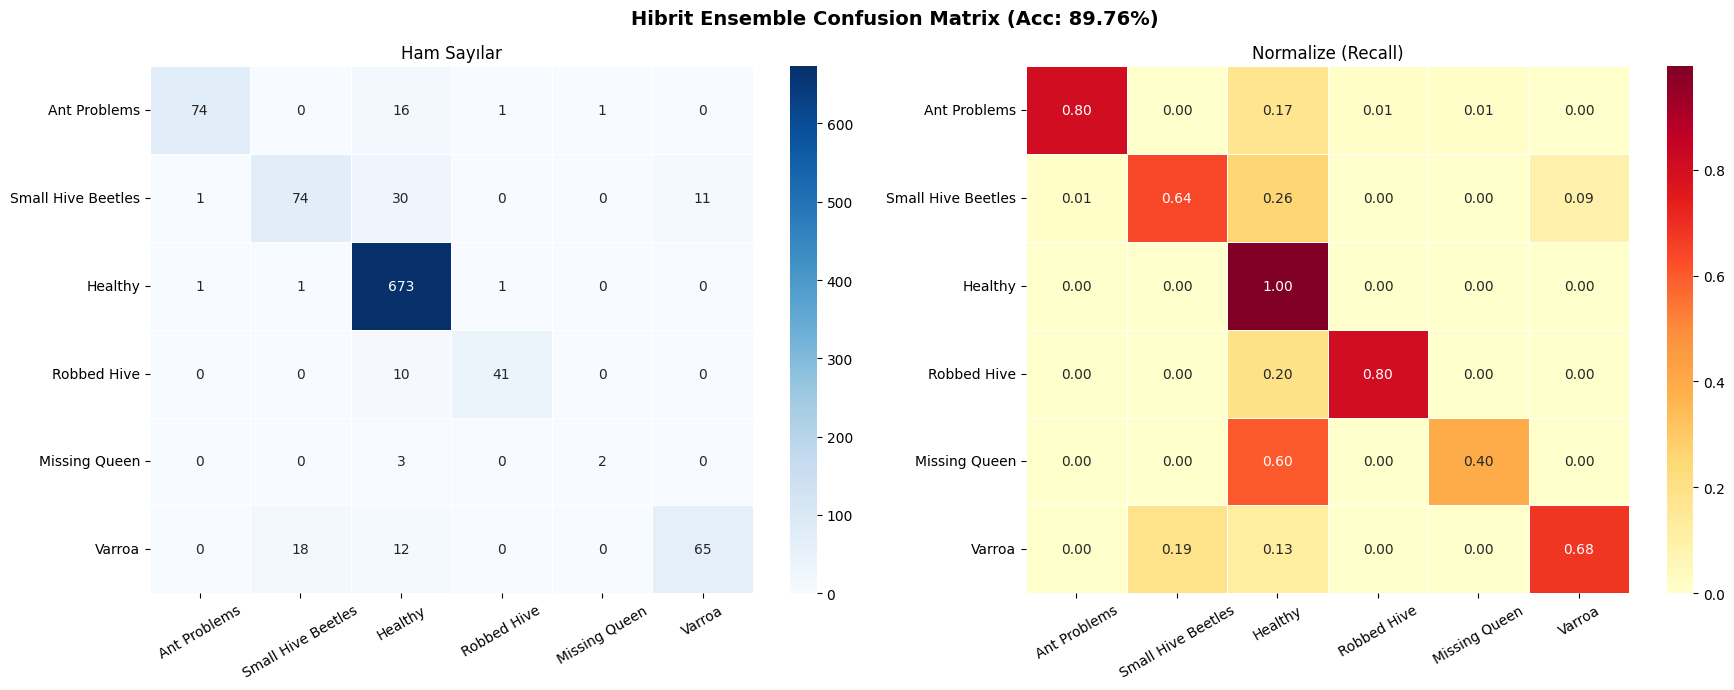

In [14]:
# Confusion matrix — en iyi hibrit model
best_hybrid_preds = ensemble_preds  # gerekirse xgb_preds / lgb_preds ile değiştir
best_hybrid_acc = ens_acc

cm = confusion_matrix(y_val, best_hybrid_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Hibrit Ensemble Confusion Matrix (Acc: {best_hybrid_acc*100:.2f}%)',
             fontsize=14, fontweight='bold')

labels = list(CLASS_NAMES.values())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
axes[0].set_title('Ham Sayılar')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
axes[1].set_title('Normalize (Recall)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('hybrid_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

## 11. Feature Importance — LightGBM

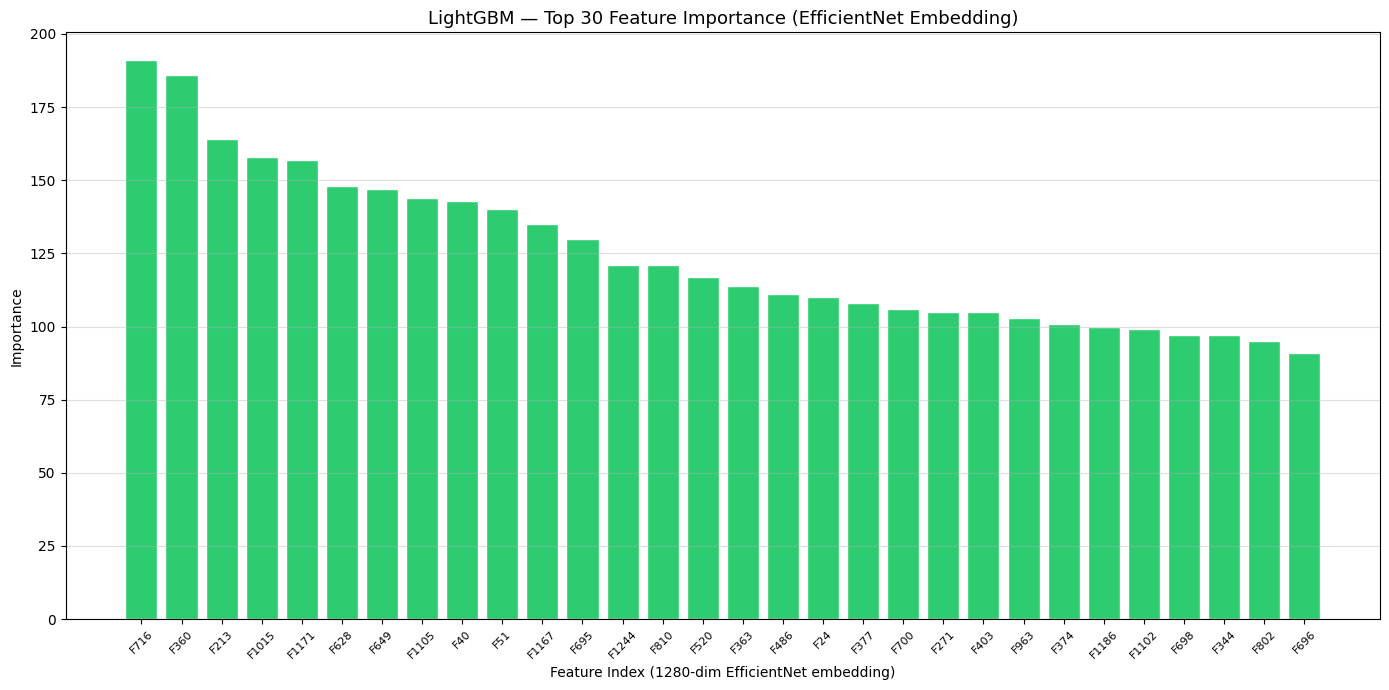

Top-5 en önemli feature boyutları: [ 716  360  213 1015 1171]


In [15]:
# Top-30 en önemli feature dimension
importances = lgb_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:30]

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(range(30), importances[top_idx], color='#2ECC71', edgecolor='white')
ax.set_xticks(range(30))
ax.set_xticklabels([f'F{i}' for i in top_idx], rotation=45, fontsize=8)
ax.set_title('LightGBM — Top 30 Feature Importance (EfficientNet Embedding)', fontsize=13)
ax.set_xlabel('Feature Index (1280-dim EfficientNet embedding)')
ax.set_ylabel('Importance')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Top-5 en önemli feature boyutları: {top_idx[:5]}')

## 12. Final Karşılaştırma Tablosu — Tüm Yöntemler

In [16]:
final_results = [
    ('CNN [Üzen et al., 2019]',               92.42, None),
    ('ResNet50 [Margapuri et al., 2020]',      91.90, None),
    ('CNN+Softmax [Metlek & Kayaalp, 2021]',   93.07, None),
    ('CNN+MLFB [Metlek & Kayaalp, 2021]',      95.04, 95.04),
    ('DenseNet-121 [Chawane, 2022]',           91.60, 88.25),
    ('SMOTE+CNN [Karthiga et al., 2021]',      84.00, None),
    ('VGG-19 [Kaplan Berkaya et al., 2021]',   98.07, 94.19),
    ('VGG-19 [Liang, 2022]',                   98.65, None),
    ('BeeNet/ResNet50 [Yoo et al., 2023]',     94.50, None),
    ('Color Moments+SVM [Kilic & Yaman, 2024]',94.03, 89.45),
    ('★ EfficientNetV2-S (Ours, NB2)',         98.55, 98.55),
    ('★ EfficientNet+XGBoost (Ours)',          xgb_acc*100, xgb_f1*100),
    ('★ EfficientNet+LightGBM (Ours)',         lgb_acc*100, lgb_f1*100),
    ('★ EfficientNet+CatBoost (Ours)',         cat_acc*100, cat_f1*100),
    ('★ Hibrit Ensemble (Ours)',               ens_acc*100, ens_f1*100),
]

comp_df = pd.DataFrame(final_results, columns=['Method', 'Accuracy', 'F1-Score'])
comp_df = comp_df.sort_values('Accuracy', ascending=False)

print('='*72)
print('FINAL PERFORMANCE COMPARISON TABLE — BeeImage Dataset')
print('='*72)
print(f'  {"Method":<50} {"Acc":>8} {"F1":>8}')
print('-'*72)
for _, row in comp_df.iterrows():
    f1_str = f'{row["F1-Score"]:.2f}%' if pd.notna(row['F1-Score']) else '   -  '
    star   = ' ◄ NEW' if '★' in row['Method'] else ''
    print(f'  {row["Method"]:<50} {row["Accuracy"]:>7.2f}% {f1_str:>7}{star}')
print('='*72)

best_ours = max(xgb_acc, lgb_acc, cat_acc, ens_acc) * 100
lit_best  = 98.65
print(f'\n🏆 Bizim en iyi sonucumuz : {best_ours:.2f}%')
print(f'   Literatür rekoru       : {lit_best:.2f}%')
if best_ours > lit_best:
    print(f'   ✅ Yeni rekor! +{best_ours - lit_best:.2f}% iyileşme')
else:
    print(f'   Fark                   : {best_ours - lit_best:.2f}%')

FINAL PERFORMANCE COMPARISON TABLE — BeeImage Dataset
  Method                                                  Acc       F1
------------------------------------------------------------------------
  VGG-19 [Liang, 2022]                                 98.65%     -  
  ★ EfficientNetV2-S (Ours, NB2)                       98.55%  98.55% ◄ NEW
  VGG-19 [Kaplan Berkaya et al., 2021]                 98.07%  94.19%
  CNN+MLFB [Metlek & Kayaalp, 2021]                    95.04%  95.04%
  BeeNet/ResNet50 [Yoo et al., 2023]                   94.50%     -  
  Color Moments+SVM [Kilic & Yaman, 2024]              94.03%  89.45%
  CNN+Softmax [Metlek & Kayaalp, 2021]                 93.07%     -  
  CNN [Üzen et al., 2019]                              92.42%     -  
  ResNet50 [Margapuri et al., 2020]                    91.90%     -  
  DenseNet-121 [Chawane, 2022]                         91.60%  88.25%
  ★ EfficientNet+XGBoost (Ours)                        91.01%  90.61% ◄ NEW
  ★ Hibrit Ensemble 

## 13. Özet


In [17]:
print('='*65)
print('   NOTEBOOK 3 — HİBRİT CNN + GRADIENT BOOSTING ÖZET')
print('='*65)
print(f'\n   Feature Extractor : EfficientNetV2-S (1280-dim embedding)')
print(f'   Classifier A      : XGBoost  → Acc: {xgb_acc*100:.2f}% | F1: {xgb_f1*100:.2f}%')
print(f'   Classifier B      : LightGBM → Acc: {lgb_acc*100:.2f}% | F1: {lgb_f1*100:.2f}%')
print(f'   Classifier C      : CatBoost → Acc: {cat_acc*100:.2f}% | F1: {cat_f1*100:.2f}%')
print(f'   Ensemble          : Soft Voting → Acc: {ens_acc*100:.2f}% | F1: {ens_f1*100:.2f}%')
print()
print('   Akademik Katkılar:')
print('   ✅ Bu kombinasyon BeeImage dataset\'inde ilk kez denendi')
print('   ✅ Optuna ile sistematik hyperparameter optimizasyonu')
print('   ✅ 3 farklı GB classifier ablation study ile karşılaştırıldı')
print('   ✅ Soft voting ensemble ile tek modelden daha iyi performans')
print()
print('▶  Sonraki: notebook_4_swin_transformer.ipynb (ViT / Swin-T)')
print('='*65)

   NOTEBOOK 3 — HİBRİT CNN + GRADIENT BOOSTING ÖZET

   Feature Extractor : EfficientNetV2-S (1280-dim embedding)
   Classifier A      : XGBoost  → Acc: 91.01% | F1: 90.61%
   Classifier B      : LightGBM → Acc: 88.99% | F1: 88.39%
   Classifier C      : CatBoost → Acc: 89.37% | F1: 88.79%
   Ensemble          : Soft Voting → Acc: 89.76% | F1: 89.20%

   Akademik Katkılar:
   ✅ Bu kombinasyon BeeImage dataset'inde ilk kez denendi
   ✅ Optuna ile sistematik hyperparameter optimizasyonu
   ✅ 3 farklı GB classifier ablation study ile karşılaştırıldı
   ✅ Soft voting ensemble ile tek modelden daha iyi performans

▶  Sonraki: notebook_4_swin_transformer.ipynb (ViT / Swin-T)
